# Proyecto 1 — ML (CS3061): Clasificación de *Churn* en Telco

**Curso:** Machine Learning · UTEC  
**Dataset:** Telco Customer Churn, usando los archivos oficiales `train.csv` y `test.csv`.  
**Seed:** 42 (replicabilidad garantizada).

Este notebook contiene el pipeline completo:
1. Preprocesamiento + Feature Engineering
2. EDA
3. Modelos: Regresión Logística + Random Forest con CV estratificada y GridSearch
4. Matriz de costos + threshold óptimo para análisis costo-beneficio
5. Submission con threshold optimizado por F1-score para Kaggle/Cadem
6. Generación de predicciones finales sobre `test.csv`

## 0. Setup

In [4]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn imbalanced-learn

    pytz>=2011n
        ~~~~~~^


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

In [6]:
train_raw = pd.read_csv("../train.csv")
test_raw = pd.read_csv("../test.csv")

# Por ahora trabajaremos solo con train_raw, porque tiene la variable objetivo Churn.
# test_raw se usará al final solo para predicciones finales.
df_raw = train_raw.copy()

print("Train shape:", train_raw.shape)
print("Test shape:", test_raw.shape)

print("\n¿Train tiene Churn?", "Churn" in train_raw.columns)
print("¿Test tiene Churn?", "Churn" in test_raw.columns)

display(train_raw.head())
display(test_raw.head())

Train shape: (5634, 21)
Test shape: (1409, 20)

¿Train tiene Churn? True
¿Test tiene Churn? False


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4223-BKEOR,Female,0,No,Yes,21,Yes,No,DSL,Yes,...,Yes,No,No,Yes,One year,No,Mailed check,64.85,1336.8,No
1,6035-RIIOM,Female,0,No,No,54,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),97.20,5129.45,No
2,3797-VTIDR,Male,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,23.45,23.45,Yes
3,2568-BRGYX,Male,0,No,No,4,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.20,237.95,Yes
4,2775-SEFEE,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,,No


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8
1,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45
2,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7
3,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35
4,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1


## 1. Preprocesamiento

Pasos:
- Se cargaron los archivos oficiales `train.csv` y `test.csv`.
- El archivo `train.csv` se utilizó para entrenamiento, validación y evaluación interna, ya que contiene la variable objetivo `Churn`.
- El archivo `test.csv` no contiene `Churn`, por lo que se reservó únicamente para generar predicciones finales.
- Se eliminó `customerID` como variable predictora, conservándolo solo para identificar las predicciones finales del test oficial.
- `TotalCharges`: conversión de string a float e imputación de valores faltantes usando la mediana calculada solo con el conjunto de entrenamiento.
- Se colapsó `No internet service` → `No` en las 6 columnas de servicios de internet y `No phone service` → `No` en `MultipleLines`.
- **Feature engineering**: se crearon 4 variables nuevas: `tenure_bucket`, `avg_charges_per_month`, `num_services` e `is_new_customer`.
- Encoding: variables binarias transformadas a 0/1 y variables multiclase codificadas con One-Hot Encoding usando `drop_first=True`.
- Se alinearon las columnas del train y del test oficial para asegurar que ambos tengan las mismas variables después del encoding.
- Se realizó una división estratificada 80/20 del `train.csv`: 80% para train interno y 20% para validación.
- `StandardScaler` fue ajustado solo con el train interno y luego aplicado a validación y test oficial para evitar data leakage.

In [7]:
SERVICE_COLS = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

SCALED_NUMERIC = ['tenure', 'MonthlyCharges', 'TotalCharges',
                  'avg_charges_per_month', 'num_services']


def clean(df, total_charges_median=None):
    df = df.copy()
    # Guardamos customerID si existe, pero no lo usamos como feature
    if 'customerID' in df.columns:
        df = df.drop(columns=['customerID'])
    # Convertir TotalCharges a numérico
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    # La mediana debe salir del train, no del test
    if total_charges_median is None:
        total_charges_median = df['TotalCharges'].median()
    df['TotalCharges'] = df['TotalCharges'].fillna(total_charges_median)
    # Unificar categorías equivalentes
    for c in SERVICE_COLS:
        df[c] = df[c].replace({'No internet service': 'No'})
    df['MultipleLines'] = df['MultipleLines'].replace({'No phone service': 'No'})
    return df, total_charges_median


def feature_engineer(df):
    df = df.copy()
    df['tenure_bucket'] = pd.cut(
        df['tenure'],
        bins=[-0.1, 12, 24, 48, 100],
        labels=['0-12m', '12-24m', '24-48m', '48m+']
    ).astype(str)
    df['avg_charges_per_month'] = df['TotalCharges'] / df['tenure'].replace(0, 1)
    services = SERVICE_COLS + ['PhoneService', 'MultipleLines']
    df['num_services'] = sum((df[c] == 'Yes').astype(int) for c in services)
    df['is_new_customer'] = (df['tenure'] <= 6).astype(int)
    return df


def encode_features(df):
    df = df.copy()
    # Variables binarias
    df['gender'] = (df['gender'] == 'Male').astype(int)
    for c in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
        df[c] = (df[c] == 'Yes').astype(int)
    for c in SERVICE_COLS + ['MultipleLines']:
        df[c] = (df[c] == 'Yes').astype(int)
    # One-hot encoding
    cat = ['InternetService', 'Contract', 'PaymentMethod', 'tenure_bucket']
    df = pd.get_dummies(df, columns=cat, drop_first=True, dtype=int)

    return df

In [8]:
# =========================
# Preprocesamiento train/test
# =========================

# Guardar IDs del test oficial para el archivo final de predicciones
test_customer_ids = test_raw['customerID'].copy()

# Separar variable objetivo del train
y = (train_raw['Churn'] == 'Yes').astype(int)
X_raw = train_raw.drop(columns=['Churn'])

# Limpiar train y obtener mediana del train
X_clean, total_charges_median = clean(X_raw)

# Limpiar test usando la mediana del train
X_test_oficial_clean, _ = clean(test_raw, total_charges_median=total_charges_median)

# Feature engineering
X_fe = feature_engineer(X_clean)
X_test_oficial_fe = feature_engineer(X_test_oficial_clean)

# Encoding
X_enc = encode_features(X_fe)
X_test_oficial_enc = encode_features(X_test_oficial_fe)

# Alinear columnas para que train y test oficial tengan exactamente las mismas features
X_enc, X_test_oficial_enc = X_enc.align(
    X_test_oficial_enc,
    join='left',
    axis=1,
    fill_value=0
)

print("Shape X train completo:", X_enc.shape)
print("Shape test oficial:", X_test_oficial_enc.shape)
print("Churn rate train completo:", y.mean().round(3))

Shape X train completo: (5634, 29)
Shape test oficial: (1409, 29)
Churn rate train completo: 0.266


In [9]:
# =========================
# División interna del train.csv
# =========================

X_train, X_val, y_train, y_val = train_test_split(
    X_enc,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print(f"Train interno: {X_train.shape}")
print(f"Validation: {X_val.shape}")

print(f"Churn rate train={y_train.mean():.3f}")
print(f"Churn rate val={y_val.mean():.3f}")

Train interno: (4507, 29)
Validation: (1127, 29)
Churn rate train=0.266
Churn rate val=0.265


In [10]:
# =========================
# Escalado numérico
# =========================

scaler = StandardScaler()

X_train[SCALED_NUMERIC] = scaler.fit_transform(X_train[SCALED_NUMERIC])
X_val[SCALED_NUMERIC] = scaler.transform(X_val[SCALED_NUMERIC])
X_test_oficial_enc[SCALED_NUMERIC] = scaler.transform(X_test_oficial_enc[SCALED_NUMERIC])

print("Escalado aplicado correctamente.")

Escalado aplicado correctamente.


## 2. EDA

In [11]:
# =========================
# EDA - Exploratory Data Analysis
# =========================

# Usamos solo train_raw porque es el único archivo que contiene la variable objetivo Churn
df_eda = train_raw.copy()

# Convertir TotalCharges a numérico para análisis
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')
df_eda['TotalCharges'] = df_eda['TotalCharges'].fillna(df_eda['TotalCharges'].median())

print("Shape train:", df_eda.shape)
print("Churn rate:", (df_eda['Churn'] == 'Yes').mean().round(3))
df_eda.head()

Shape train: (5634, 21)
Churn rate: 0.266


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4223-BKEOR,Female,0,No,Yes,21,Yes,No,DSL,Yes,...,Yes,No,No,Yes,One year,No,Mailed check,64.85,1336.80,No
1,6035-RIIOM,Female,0,No,No,54,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),97.20,5129.45,No
2,3797-VTIDR,Male,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,23.45,23.45,Yes
3,2568-BRGYX,Male,0,No,No,4,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.20,237.95,Yes
4,2775-SEFEE,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,1410.80,No


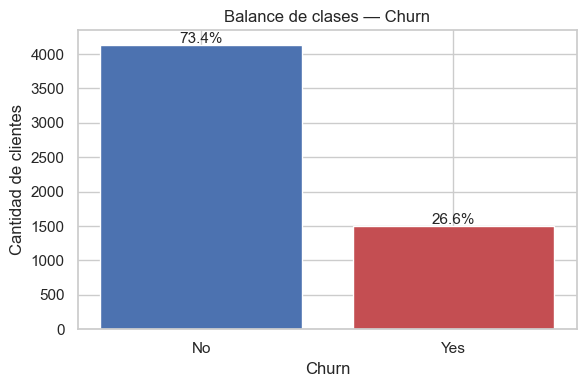

In [12]:
# Figura 1: Balance de clases
counts = df_eda['Churn'].value_counts()
pct = counts / counts.sum() * 100
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=['#4C72B0', '#C44E52'])
for b, p in zip(bars, pct.values):
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height() + 30,
        f'{p:.1f}%',
        ha='center'
    )
ax.set_title('Balance de clases — Churn')
ax.set_xlabel('Churn')
ax.set_ylabel('Cantidad de clientes')
plt.tight_layout()
plt.show()

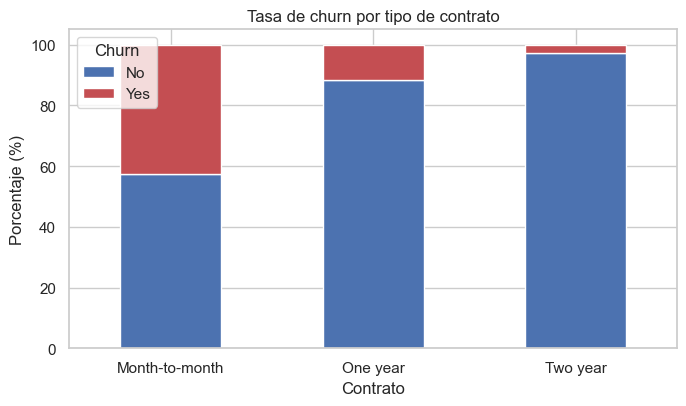

Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.2  11.8
Two year        97.2   2.8


In [13]:
# Figura 2: Churn por contrato
ct = pd.crosstab(
    df_eda['Contract'],
    df_eda['Churn'],
    normalize='index'
) * 100

ct = ct.loc[['Month-to-month', 'One year', 'Two year']]
fig, ax = plt.subplots(figsize=(7, 4.2))
ct.plot(kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#C44E52'])
ax.set_title('Tasa de churn por tipo de contrato')
ax.set_xlabel('Contrato')
ax.set_ylabel('Porcentaje (%)')
ax.legend(title='Churn')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(ct.round(1))

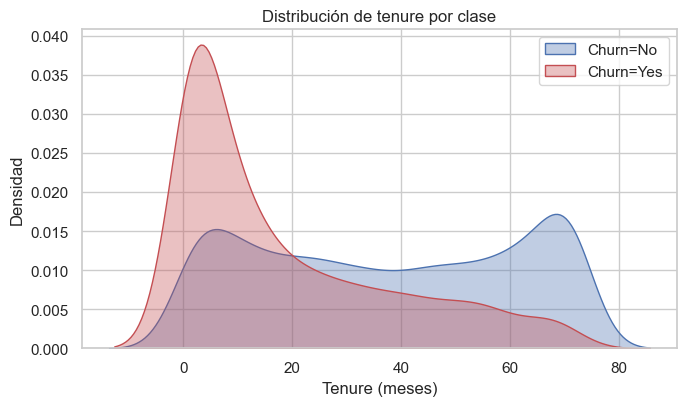

In [14]:
# Figura 3: Tenure por clase
fig, ax = plt.subplots(figsize=(7, 4.2))
for label, color in [('No', '#4C72B0'), ('Yes', '#C44E52')]:
    sns.kdeplot(
        df_eda.loc[df_eda['Churn'] == label, 'tenure'],
        ax=ax,
        label=f'Churn={label}',
        color=color,
        fill=True, alpha=0.35
    )
ax.set_title('Distribución de tenure por clase')
ax.set_xlabel('Tenure (meses)')
ax.set_ylabel('Densidad')
ax.legend()
plt.tight_layout()
plt.show()

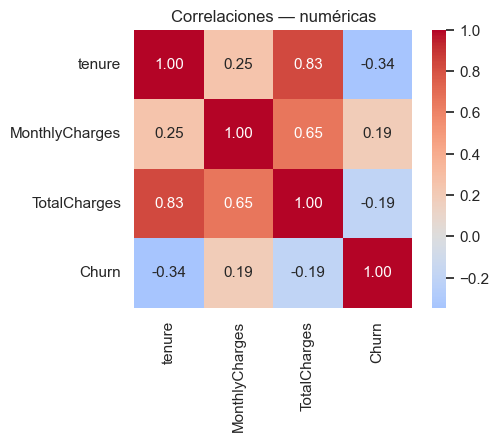

In [15]:
# Figura 4: Heatmap correlaciones
num = df_eda[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
num['Churn'] = (df_eda['Churn'] == 'Yes').astype(int)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(
    num.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    ax=ax
)
ax.set_title('Correlaciones — numéricas')
plt.tight_layout()
plt.show()

## 3. Modelado: LogReg + Random Forest

- Se entrenaron dos modelos: **Regresión Logística L2** y **Random Forest**.
- La Regresión Logística es interpretable y usa regularización L2 para controlar sobreajuste.
- Random Forest permite capturar relaciones no lineales e interacciones entre variables.
- Se utilizó `StratifiedKFold(5)` para preservar la proporción de clases en cada fold.
- Se aplicó `GridSearchCV` optimizando F1-score, priorizando la clase positiva `Churn`.
- `class_weight='balanced'` ayuda a mitigar el desbalance de clases sin aplicar re-muestreo.
- Los modelos se entrenaron con `X_train`; la validación se usó para reportar métricas internas y ajustar los thresholds.

In [ ]:
# =========================
# 3. Modelado: LogReg + Random Forest
# =========================
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED)
# Regresión Logística
lr_grid = {'C': [0.01, 0.1, 1.0, 10.0]}
lr = LogisticRegression( max_iter=2000, class_weight='balanced',penalty='l2',solver='lbfgs',random_state=SEED)
gs_lr = GridSearchCV(lr,lr_grid,scoring='f1',cv=cv,n_jobs=-1)
gs_lr.fit(X_train, y_train)
print(f"[LR] best={gs_lr.best_params_} | CV F1={gs_lr.best_score_:.4f}")

    # Random Forest
    rf_grid = {'n_estimators': [200, 400],'max_depth': [None, 10, 20],'min_samples_split': [2, 10]}
    rf = RandomForestClassifier(class_weight='balanced',random_state=SEED,n_jobs=-1)
    gs_rf = GridSearchCV(rf,rf_grid,scoring='f1',cv=cv,n_jobs=-1)
    gs_rf.fit(X_train, y_train)
    print(f"[RF] best={gs_rf.best_params_} | CV F1={gs_rf.best_score_:.4f}")

c:\Users\joeld\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[LR] best={'C': 0.1} | CV F1=0.6230
[RF] best={'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200} | CV F1=0.6245


In [17]:
# Evaluación inicial en validación con threshold = 0.5
y_pred_lr_05 = gs_lr.predict(X_val)
y_pred_rf_05 = gs_rf.predict(X_val)

proba_lr_val = gs_lr.predict_proba(X_val)[:, 1]
proba_rf_val = gs_rf.predict_proba(X_val)[:, 1]
def metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred)
    }

tabla_05 = pd.DataFrame({
    'LogReg': metrics(y_val, y_pred_lr_05),
    'RandomForest': metrics(y_val, y_pred_rf_05)
}).T.round(4)

print("=== Métricas en VALIDACIÓN (threshold=0.5) ===")
tabla_05

=== Métricas en VALIDACIÓN (threshold=0.5) ===


,accuracy,f1,precision,recall
LogReg,0.7560,0.6377,0.5261,0.8094
RandomForest,0.7728,0.6311,0.5544,0.7324


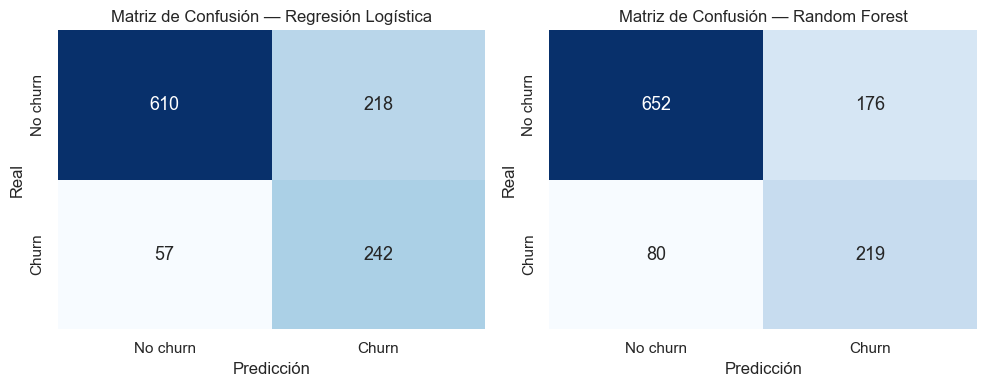

In [37]:
# =========================
# Matrices de confusión con threshold = 0.5
# =========================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cms = [
    confusion_matrix(y_val, y_pred_lr_05),
    confusion_matrix(y_val, y_pred_rf_05)
]
titles = ['Regresión Logística','Random Forest']
for ax, cm, title in zip(axes, cms, titles):
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False,ax=ax,
        xticklabels=['No churn', 'Churn'],
        yticklabels=['No churn', 'Churn'],
        annot_kws={'size': 13}
    )
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_title(f'Matriz de Confusión — {title}')
plt.tight_layout()
plt.show()

## 4. Matriz de Costos + Threshold óptimo

| Real \ Predicción | No churn | Churn |
|---|---|---|
| No churn | \$0 (TN) | \$20 (FP) |
| Churn    | \$400 (FN) | \$50 (TP) |

Asimetría 20:1 entre FN y FP → penaliza no detectar churners.

El threshold óptimo se selecciona usando el conjunto de validación, siguiendo la matriz de costos definida. Este análisis se usa para justificar el ajuste del umbral en el informe.

In [19]:
C_TN, C_FP, C_FN, C_TP = 0, 20, 400, 50

def total_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn*C_TN + fp*C_FP + fn*C_FN + tp*C_TP

proba_lr_val = gs_lr.predict_proba(X_val)[:, 1]
proba_rf_val = gs_rf.predict_proba(X_val)[:, 1]

ths = np.linspace(0.05, 0.95, 91)
c_lr = np.array([total_cost(y_val, (proba_lr_val >= t).astype(int)) for t in ths])
c_rf = np.array([total_cost(y_val, (proba_rf_val >= t).astype(int)) for t in ths])

best_t_lr, best_t_rf = ths[c_lr.argmin()], ths[c_rf.argmin()]
best_c_lr, best_c_rf = c_lr.min(), c_rf.min()
default_c_lr = total_cost(y_val, (proba_lr_val >= 0.5).astype(int))
default_c_rf = total_cost(y_val, (proba_rf_val >= 0.5).astype(int))

print(f'LogReg:  t=0.5 → ${default_c_lr:,}    t*={best_t_lr:.2f} → ${best_c_lr:,}')
print(f'RForest: t=0.5 → ${default_c_rf:,}    t*={best_t_rf:.2f} → ${best_c_rf:,}')

winner = 'LogReg' if best_c_lr <= best_c_rf else 'RandomForest'
w_t = best_t_lr if winner=='LogReg' else best_t_rf
w_proba_val = proba_lr_val if winner=='LogReg' else proba_rf_val
w_cost_val = min(best_c_lr, best_c_rf)
w_base_val = default_c_lr if winner=='LogReg' else default_c_rf
print(f'\n>>> Ganador: {winner}  t*={w_t:.2f}  costo_val=${w_cost_val:,}  ahorro_val={(w_base_val-w_cost_val)/w_base_val*100:.1f}%')

LogReg:  t=0.5 → $39,260    t*=0.21 → $27,560
RForest: t=0.5 → $46,470    t*=0.12 → $27,550

>>> Ganador: RandomForest  t*=0.12  costo_val=$27,550  ahorro_val=40.7%


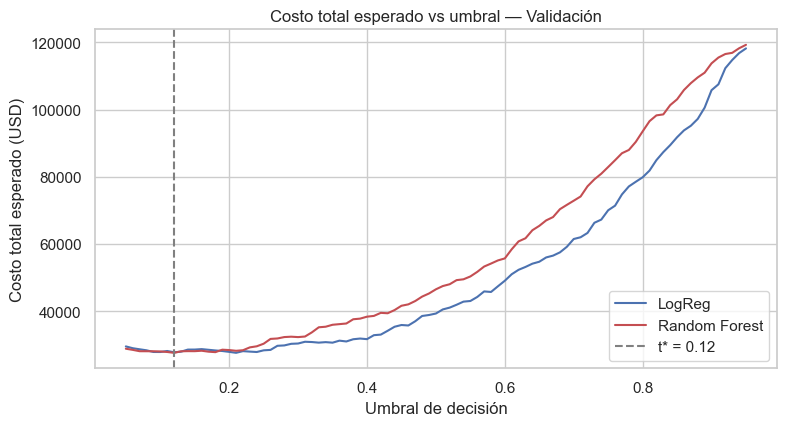

In [20]:
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(ths, c_lr, label='LogReg', color='#4C72B0')
ax.plot(ths, c_rf, label='Random Forest', color='#C44E52')
ax.axvline(w_t, color='gray', ls='--', label=f't* = {w_t:.2f}')
ax.set_xlabel('Umbral de decisión'); ax.set_ylabel('Costo total esperado (USD)')
ax.set_title('Costo total esperado vs umbral — Validación')
ax.legend()
plt.tight_layout(); plt.show()

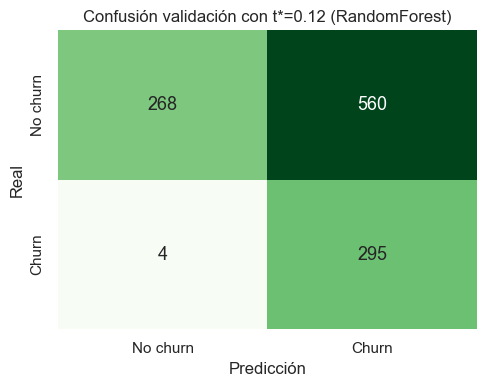

              precision    recall  f1-score   support

    No churn       0.99      0.32      0.49       828
       Churn       0.35      0.99      0.51       299

    accuracy                           0.50      1127
   macro avg       0.67      0.66      0.50      1127
weighted avg       0.82      0.50      0.49      1127

Costo validación con t=0.5: $46,470
Costo validación con t*=0.12: $27,550
Ahorro en validación: 40.7%


In [21]:
y_pred_opt = (w_proba_val >= w_t).astype(int)
cm = confusion_matrix(y_val, y_pred_opt)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['No churn', 'Churn'],
            yticklabels=['No churn', 'Churn'], ax=ax, annot_kws={'size': 13})
ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
ax.set_title(f'Confusión validación con t*={w_t:.2f} ({winner})')
plt.tight_layout(); plt.show()

print(classification_report(y_val, y_pred_opt, target_names=['No churn', 'Churn']))

val_cost_opt = total_cost(y_val, y_pred_opt)
val_cost_default = total_cost(y_val, (w_proba_val >= 0.5).astype(int))

print(f'Costo validación con t=0.5: ${val_cost_default:,}')
print(f'Costo validación con t*={w_t:.2f}: ${val_cost_opt:,}')
print(f'Ahorro en validación: {(val_cost_default-val_cost_opt)/val_cost_default*100:.1f}%')

### Comparación de thresholds alternativos

Se compararon distintos thresholds para observar cómo cambia la matriz de confusión y las métricas del modelo. Esto permite analizar el trade-off entre reducir falsos negativos, controlar falsos positivos y mejorar F1-score.

In [23]:
# Comparación de thresholds para analizar matriz de confusión

def resumen_threshold(y_true, proba, thresholds, model_name):
    rows = []

    for t in thresholds:
        y_pred = (proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        rows.append({
            'modelo': model_name,
            'threshold': t,
            'TN': tn,
            'FP': fp,
            'FN': fn,
            'TP': tp,
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred),
            'recall': recall_score(y_true, y_pred),
            'f1': f1_score(y_true, y_pred),
            'costo': total_cost(y_true, y_pred)
        })

    return pd.DataFrame(rows)


thresholds_comparar = [0.12, 0.20, 0.30, 0.40, 0.50, 0.55]
tabla_thr_rf = resumen_threshold(
    y_val,
    proba_rf_val,
    thresholds_comparar,
    'RandomForest'
)

tabla_thr_lr = resumen_threshold(
    y_val,
    proba_lr_val,
    thresholds_comparar,
    'LogReg'
)

tabla_thresholds = pd.concat([tabla_thr_rf, tabla_thr_lr], ignore_index=True)

tabla_thresholds.round(4)

,modelo,threshold,TN,FP,FN,TP,accuracy,precision,recall,f1,costo
0,RandomForest,0.12,268,560,4,295,0.4996,0.3450,0.9866,0.5113,27550
1,RandomForest,0.20,384,444,13,286,0.5945,0.3918,0.9565,0.5559,28380
2,RandomForest,0.30,506,322,31,268,0.6868,0.4542,0.8963,0.6029,32240
3,RandomForest,0.40,587,241,53,246,0.7391,0.5051,0.8227,0.6260,38320
4,RandomForest,0.50,652,176,80,219,0.7728,0.5544,0.7324,0.6311,46470
5,RandomForest,0.55,688,140,93,206,0.7933,0.5954,0.6890,0.6388,50300
6,LogReg,0.12,242,586,3,296,0.4774,0.3356,0.9900,0.5013,27720
7,LogReg,0.20,341,487,9,290,0.5599,0.3732,0.9699,0.5390,27840
8,LogReg,0.30,444,384,22,277,0.6398,0.4191,0.9264,0.5771,30330
9,LogReg,0.40,519,309,30,269,0.6992,0.4654,0.8997,0.6135,31630


El threshold que minimiza el costo esperado fue 0.12 para Random Forest. Sin embargo, al analizar la matriz de confusión se observa que este umbral genera una cantidad elevada de falsos positivos: 560 clientes que realmente no se irían fueron clasificados como churn. A cambio, el modelo solo deja 4 falsos negativos, es decir, casi no deja escapar clientes que sí harían churn. Esto ocurre porque la matriz de costos penaliza fuertemente los falsos negativos, empujando al modelo a ser muy sensible.

Por ello, se evaluaron thresholds alternativos para encontrar un punto de equilibrio entre costo, recall, precision y cantidad de falsas alarmas. Como alternativa más equilibrada, se considera Regresión Logística con threshold 0.40, ya que reduce los falsos positivos de 560 a 309, mantiene un recall alto de 0.8997 y conserva un costo esperado menor que el threshold base de 0.5. En ese sentido, el threshold 0.12 se interpreta como el mínimo costo teórico, mientras que el threshold 0.40 representa una opción más razonable desde una perspectiva operativa.

## 5. Predicciones finales bajo criterios de costo-beneficio

El archivo `test.csv` oficial no contiene la variable objetivo `Churn`, por lo que no se utiliza para calcular métricas. En esta sección se generan predicciones finales usando criterios de costo-beneficio derivados de la matriz de costos.

El primer criterio corresponde al threshold que minimiza el costo esperado de forma estricta: Random Forest con threshold 0.12. Este umbral reduce fuertemente los falsos negativos, pero genera una cantidad elevada de falsos positivos.

Por ello, también se considera una alternativa operativa más equilibrada: Regresión Logística con threshold 0.40. Esta opción no alcanza el costo mínimo absoluto, pero reduce considerablemente los falsos positivos, mantiene un recall alto y conserva un costo esperado menor que el threshold base de 0.5.

In [24]:
# 5. Predicciones finales bajo criterios de costo-beneficio

# Criterio 1: costo mínimo estricto
final_model_cost_min = gs_rf
threshold_cost_min = 0.12

proba_test_oficial_cost_min = final_model_cost_min.predict_proba(X_test_oficial_enc)[:, 1]
pred_test_oficial_cost_min = (proba_test_oficial_cost_min >= threshold_cost_min).astype(int)

submission_cost_min = pd.DataFrame({
    'customerID': test_customer_ids,
    'Churn': pred_test_oficial_cost_min
})

submission_cost_min['Churn'] = submission_cost_min['Churn'].map({0: 'No', 1: 'Yes'})

print("Submission costo mínimo:")
print(submission_cost_min.head())
print(submission_cost_min['Churn'].value_counts())

submission_cost_min.to_csv('../submission_threshold_costo_minimo.csv', index=False)
print("Archivo guardado: submission_threshold_costo_minimo.csv")

Submission costo mínimo:
   customerID Churn
0  1024-GUALD   Yes
1  0484-JPBRU   Yes
2  3620-EHIMZ    No
3  6910-HADCM   Yes
4  8587-XYZSF    No
Churn
Yes    1040
No      369
Name: count, dtype: int64
Archivo guardado: submission_threshold_costo_minimo.csv


In [25]:
# Criterio 2: alternativa costo-beneficio más equilibrada
final_model_operativo = gs_lr
threshold_operativo = 0.40

proba_test_oficial_operativo = final_model_operativo.predict_proba(X_test_oficial_enc)[:, 1]
pred_test_oficial_operativo = (proba_test_oficial_operativo >= threshold_operativo).astype(int)

submission_operativo = pd.DataFrame({
    'customerID': test_customer_ids,
    'Churn': pred_test_oficial_operativo
})

submission_operativo['Churn'] = submission_operativo['Churn'].map({0: 'No', 1: 'Yes'})

print("Submission criterio operativo:")
print(submission_operativo.head())
print(submission_operativo['Churn'].value_counts())

submission_operativo.to_csv('../submission_threshold_operativo.csv', index=False)
print("Archivo guardado: submission_threshold_operativo.csv")

Submission criterio operativo:
   customerID Churn
0  1024-GUALD   Yes
1  0484-JPBRU    No
2  3620-EHIMZ    No
3  6910-HADCM   Yes
4  8587-XYZSF    No
Churn
Yes    719
No     690
Name: count, dtype: int64
Archivo guardado: submission_threshold_operativo.csv


In [35]:
resumen_costo_beneficio = pd.DataFrame({
    'Criterio': ['Costo mínimo', 'Costo-beneficio operativo'],
    'Modelo': ['RandomForest', 'LogReg'],
    'Threshold': [0.12, 0.40],
    'Ventaja': [
        'Menor costo esperado',
        'Menos falsos positivos'
    ],
    'Observación': [
        'Genera muchos FP',
        'Mantiene recall alto y costo menor que t=0.5'
    ]
})

resumen_costo_beneficio

,Criterio,Modelo,Threshold,Ventaja,Observación
0,Costo mínimo,RandomForest,0.12,Menor costo esperado,Genera muchos FP
1,Costo-beneficio operativo,LogReg,0.40,Menos falsos positivos,Mantiene recall alto y costo menor que t=0.5


Se generaron dos archivos de predicción bajo criterios de costo-beneficio: uno con el threshold de costo mínimo (`submission_threshold_costo_minimo.csv`) y otro con el threshold operativo balanceado (`submission_threshold_operativo.csv`). El primero prioriza minimizar el costo esperado, mientras que el segundo busca reducir falsas alarmas manteniendo un recall alto.

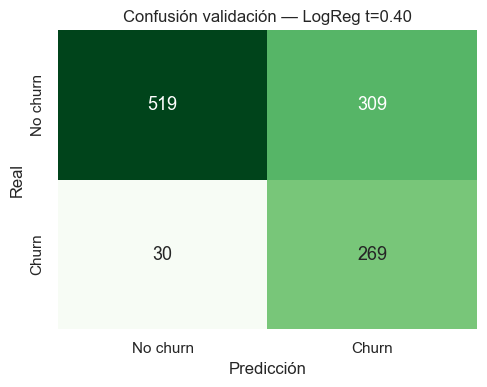

              precision    recall  f1-score   support

    No churn       0.95      0.63      0.75       828
       Churn       0.47      0.90      0.61       299

    accuracy                           0.70      1127
   macro avg       0.71      0.76      0.68      1127
weighted avg       0.82      0.70      0.72      1127

Costo validación con LogReg t=0.40: $31,630
Accuracy: 0.6992
Precision: 0.4654
Recall: 0.8997
F1-score: 0.6135


In [36]:
# Matriz de confusión para la alternativa costo-beneficio operativa
# Modelo: LogReg, threshold = 0.40

threshold_operativo = 0.40

proba_lr_val = gs_lr.predict_proba(X_val)[:, 1]
y_pred_operativo = (proba_lr_val >= threshold_operativo).astype(int)

cm_operativo = confusion_matrix(y_val, y_pred_operativo)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_operativo,
    annot=True,
    fmt='d',
    cmap='Greens',
    cbar=False,
    xticklabels=['No churn', 'Churn'],
    yticklabels=['No churn', 'Churn'],
    ax=ax,
    annot_kws={'size': 13}
)

ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Confusión validación — LogReg t=0.40')

plt.tight_layout()
plt.show()

print(classification_report(y_val, y_pred_operativo, target_names=['No churn', 'Churn']))

costo_operativo = total_cost(y_val, y_pred_operativo)

print(f'Costo validación con LogReg t=0.40: ${costo_operativo:,}')
print(f'Accuracy: {accuracy_score(y_val, y_pred_operativo):.4f}')
print(f'Precision: {precision_score(y_val, y_pred_operativo):.4f}')
print(f'Recall: {recall_score(y_val, y_pred_operativo):.4f}')
print(f'F1-score: {f1_score(y_val, y_pred_operativo):.4f}')

Esta matriz de confusión corresponde a la alternativa costo-beneficio operativa. A diferencia del threshold 0.12, esta configuración reduce considerablemente los falsos positivos, aunque permite un mayor número de falsos negativos. Por ello, se interpreta como una opción más equilibrada entre detección de churners y control de falsas alarmas.

## 6. Submission Kaggle/Cadem optimizada por F1-score

Aunque la sección anterior analiza thresholds desde un criterio de costo-beneficio, la evaluación oficial de Kaggle/Cadem utiliza F1-score. Por esta razón, se selecciona un threshold específico para maximizar F1 sobre el conjunto de validación.

In [ ]:
# 6. Threshold optimizado por F1-score para Kaggle/Cadem

ths = np.linspace(0.05, 0.95, 91)

f1_lr = np.array([f1_score(y_val, (proba_lr_val >= t).astype(int)) for t in ths])
f1_rf = np.array([f1_score(y_val, (proba_rf_val >= t).astype(int)) for t in ths])

best_t_f1_lr, best_t_f1_rf = ths[f1_lr.argmax()], ths[f1_rf.argmax()]
best_f1_lr, best_f1_rf = f1_lr.max(), f1_rf.max()

print(f'LogReg:  t_f1={best_t_f1_lr:.2f} → F1 val={best_f1_lr:.4f}')
print(f'RForest: t_f1={best_t_f1_rf:.2f} → F1 val={best_f1_rf:.4f}')

winner_f1 = 'LogReg' if best_f1_lr >= best_f1_rf else 'RandomForest'
w_t_f1 = best_t_f1_lr if winner_f1 == 'LogReg' else best_t_f1_rf

print(f'\n>>> Ganador para Kaggle/Cadem: {winner_f1}  threshold F1={w_t_f1:.2f}')

LogReg:  t_f1=0.55 → F1 val=0.6286
RForest: t_f1=0.39 → F1 val=0.6227

>>> Ganador para Kaggle/Cadem: LogReg  threshold F1=0.55


In [ ]:
# Código para evaluar ese threshold en validación
if winner_f1 == 'LogReg':
    proba_test_f1 = gs_lr.predict_proba(X_val)[:, 1]
else:
    proba_test_f1 = gs_rf.predict_proba(X_val)[:, 1]

y_pred_f1 = (proba_test_f1 >= w_t_f1).astype(int)

print(classification_report(y_val, y_pred_f1, target_names=['No churn', 'Churn']))
print("F1 validación:", round(f1_score(y_val, y_pred_f1), 4))
print("Accuracy validación:", round(accuracy_score(y_val, y_pred_f1), 4))

              precision    recall  f1-score   support

    No churn       0.90      0.79      0.84       828
       Churn       0.57      0.76      0.65       299

    accuracy                           0.78      1127
   macro avg       0.73      0.77      0.75      1127
weighted avg       0.81      0.78      0.79      1127

F1 test interno: 0.6494
Accuracy test interno: 0.7835


In [ ]:
# Código para generar el CSV de Kaggle/Cadem
if winner_f1 == 'LogReg':
    final_model_kaggle = gs_lr
else:
    final_model_kaggle = gs_rf

proba_test_oficial_kaggle = final_model_kaggle.predict_proba(X_test_oficial_enc)[:, 1]
pred_test_oficial_kaggle = (proba_test_oficial_kaggle >= w_t_f1).astype(int)

submission_kaggle = pd.DataFrame({
    'customerID': test_customer_ids,
    'Churn': pred_test_oficial_kaggle
})

submission_kaggle['Churn'] = submission_kaggle['Churn'].map({0: 'No', 1: 'Yes'})

print(submission_kaggle.head())
print(submission_kaggle['Churn'].value_counts())

submission_kaggle.to_csv('../submission_kaggle_f1.csv', index=False)
print("Archivo guardado: submission_kaggle_f1.csv")

   customerID Churn
0  1024-GUALD   Yes
1  0484-JPBRU    No
2  3620-EHIMZ    No
3  6910-HADCM   Yes
4  8587-XYZSF    No
Churn
No     905
Yes    504
Name: count, dtype: int64
Archivo guardado: submission_kaggle_f1.csv


In [29]:
resumen_kaggle = pd.DataFrame({
    'Criterio': ['Kaggle/Cadem F1'],
    'Modelo': ['LogReg'],
    'Threshold': [0.55],
    'Motivo': ['Maximiza F1-score en validación']
})

resumen_kaggle

,Criterio,Modelo,Threshold,Motivo
0,Kaggle/Cadem F1,LogReg,0.55,Maximiza F1-score en validación


## Conclusiones

1. **Modelos**: Se compararon Regresión Logística con regularización L2 y Random Forest, usando validación cruzada estratificada y búsqueda de hiperparámetros con `GridSearchCV`.
2. **Métrica oficial**: Para Kaggle/Cadem se priorizó el F1-score. Bajo este criterio, el mejor modelo fue Regresión Logística con threshold 0.55, obteniendo F1 de validación de 0.6494 y accuracy de 0.7835.
3. **Costo mínimo**: Para el análisis costo-beneficio, el menor costo esperado se obtuvo con Random Forest y threshold 0.12, reduciendo el costo de validación de \$46,470 a \$27,550. Sin embargo, este umbral generó muchos falsos positivos.
4. **Alternativa operativa**: Como opción más equilibrada se consideró Regresión Logística con threshold 0.40, ya que redujo los falsos positivos frente al threshold 0.12, mantuvo un recall alto de 0.8997 y conservó un costo menor que el threshold base de 0.5.
5. **Trade-off**: El ajuste del threshold muestra un intercambio entre costo, recall, precision y cantidad de falsas alarmas. Un threshold bajo detecta más churners, pero aumenta falsos positivos; un threshold más alto mejora precision y accuracy, pero puede dejar escapar más clientes en riesgo.
6. **Predictores relevantes**: Variables asociadas al tipo de contrato, permanencia del cliente (`tenure`) y cargos mensuales mostraron una relación importante con la probabilidad de fuga.

## Contribution Statement

- Integrante 1 — Preprocesamiento + EDA — 25%
- Integrante 2 — Modelado + Validación cruzada — 25%
- Integrante 3 — Análisis costo-beneficio + threshold — 25%
- Integrante 4 — Submission Kaggle/Cadem + integración LaTeX — 25%